The following Lab is extracted from Yandex School of Data Analysis's course Practical_RL (Week 3 - Model-free), an excellent source for learning RL with comprehensive programnming practicals. Highly recommeded for students who want to learn more about RL. https://github.com/yandexdataschool/Practical_RL/tree/master

**My notes (Anas):** Task 1 = fill in every `<YOUR CODE HERE>` block. All my changes are inside those blocks, plus the cells marked *(my addition)*:
watching the trained taxi, a greedy test on CartPole, and an extra comparison of Q-learning vs Expected Value SARSA on CliffWalking (using the `benchmark_agents` helper from the setup cell).

In [1]:
!pip3 install -q gymnasium[classic-control]

import os
import sys
import pandas as pd
from IPython.display import clear_output

import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import clear_output
from tqdm import tqdm, trange

%matplotlib inline

SEED = 42

if "google.colab" in sys.modules and not os.path.exists(".setup_complete"):
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash

    !touch .setup_complete

# This code creates a virtual display to draw game images on.
# It will have no effect if your machine has a monitor.
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash ../xvfb start
    os.environ["DISPLAY"] = ":1"


def moving_average(x, span=100):
    return pd.DataFrame({"x": np.asarray(x)}).x.ewm(span=span).mean().values


def seed_everything(env, seed=None):
    if seed is None:
        seed = SEED
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    env.reset(seed=seed)


def visualize_agent(env, agent, max_steps=100, delay=0.1):
    """
    Visualize the agent's behavior in the environment.

    Args:
        env: The environment
        agent: The trained agent
        max_steps: Maximum number of steps to take
        delay: Time delay between steps for visualization
    """
    s, _ = env.reset()
    total_reward = 0

    for step in range(max_steps):
        # Render the environment
        clear_output(True)
        plt.figure(figsize=(8, 6))
        plt.imshow(env.render())
        plt.title(f"Step: {step}, Total Reward: {total_reward:.2f}")
        plt.axis("off")
        plt.show()

        # Get action from the agent
        a = agent.get_best_action(s)  # Use best action for visualization

        # Take a step in the environment
        next_s, r, done, _, _ = env.step(a)

        # Update state and reward
        s = next_s
        total_reward += r

        # Add delay for better visualization
        time.sleep(delay)

        if done:
            # Show final state
            clear_output(True)
            plt.figure(figsize=(8, 6))
            plt.imshow(env.render())
            plt.title(f"Final State - Steps: {step + 1}, Total Reward: {total_reward:.2f}")
            plt.axis("off")
            plt.show()
            break


def benchmark_agents(
    exp_setups,
    num_episodes=1000,
    plot_every=100,
    t_max=10000,
    span=100,
    patch_every=None,
    patch_foo=None,
    num_seeds=3,
):
    all_rewards = {}
    envs = {exp_setup["name"]: exp_setup["env"]() for exp_setup in exp_setups}
    agents_buiders = {exp_setup["name"]: exp_setup["agent_builder"] for exp_setup in exp_setups}
    train_foo = {exp_setup["name"]: exp_setup["train_foo"] for exp_setup in exp_setups}

    for seed in range(num_seeds):
        SEED = seed + 42  # Using different seeds
        agents = {agent_name: agent() for agent_name, agent in agents_buiders.items()}

        # Create a separate environment for each agent using the env function
        for agent_name, agent in agents.items():
            agents[agent_name].env = envs[agent_name]

        seed_rewards = {agent_name: [] for agent_name in agents_buiders}

        # Seed each environment separately
        for agent_name in agents:
            seed_everything(envs[agent_name], seed=SEED)

        tbar = trange(num_episodes)
        tbar.set_description(f"Seed {seed + 1}/{num_seeds}")
        for i in tbar:
            for agent_name, agent in agents.items():
                seed_rewards[agent_name].append(train_foo[agent_name](envs[agent_name], agent))
            if i % 10 == 0:
                tbar.set_postfix({agent_name: seed_rewards[agent_name][-1] for agent_name in agents}, refresh=True)

        # Store rewards for this seed
        for agent_name, rewards_list in seed_rewards.items():
            if agent_name not in all_rewards:
                all_rewards[agent_name] = []
            all_rewards[agent_name].append(rewards_list)

        # Average rewards across seeds
        avg_rewards = {
            agent_name: np.mean(np.array(seed_results), axis=0) for agent_name, seed_results in all_rewards.items()
        }

        # Calculate standard deviation for confidence intervals
        std_rewards = {
            agent_name: np.std(np.array(seed_results), axis=0) for agent_name, seed_results in all_rewards.items()
        }

        # Plot average performance across seeds with confidence tubes
        clear_output(True)
        plt.figure(figsize=(10, 6))
        for agent_name, rewards_list in avg_rewards.items():
            mean_rewards = moving_average(rewards_list, span=span)
            std_rewards_smoothed = moving_average(std_rewards[agent_name], span=span)

            # Plot mean line
            plt.plot(mean_rewards, label=f"{agent_name} (avg of {num_seeds} seeds)")

            # Plot confidence tubes (mean ± std)
            plt.fill_between(
                range(len(mean_rewards)),
                mean_rewards - std_rewards_smoothed,
                mean_rewards + std_rewards_smoothed,
                alpha=0.2,
            )

            # Draw solid contour lines for the confidence tube borders
            plt.plot(range(len(mean_rewards)), mean_rewards - std_rewards_smoothed, "--", color="gray", alpha=0.7)
            plt.plot(range(len(mean_rewards)), mean_rewards + std_rewards_smoothed, "--", color="gray", alpha=0.7)

        plt.title(
            f"{envs[list(envs.keys())[0]].spec.id} - Average performance across {num_seeds} seeds with confidence intervals"
        )
        plt.legend()
        plt.show()

    return avg_rewards

bash: ../xvfb: No such file or directory


## Seminar: Q-learning

This notebook will guide you through implementation of vanilla Q-learning algorithm.

You need to implement QLearningAgent (follow instructions for each method) and use it on a number of tests below.

**Tip**: To ensure reproducibility, use the environment’s built-in random generator.

In [2]:
import math
import random
from collections import defaultdict

import numpy as np


class QLearningAgent:
    def __init__(self, alpha, epsilon, discount, env):
        """
        Q-Learning Agent
        based on https://inst.eecs.berkeley.edu/~cs188/sp19/projects.html
        Instance variables you have access to
          - self.epsilon (exploration prob)
          - self.alpha (learning rate)
          - self.discount (discount rate aka gamma)

        Functions you should use
          - self.get_legal_actions(state) {state, hashable -> list of actions, each is hashable}
            which returns legal actions for a state
          - self.get_qvalue(state,action)
            which returns Q(state,action)
          - self.set_qvalue(state,action,value)
            which sets Q(state,action) := value
        !!!Important!!!
        Note: please avoid using self._qValues directly.
            There's a special self.get_qvalue/set_qvalue for that.
        """

        self.env = env
        self._qvalues = defaultdict(lambda: defaultdict(lambda: 0))
        self.alpha = alpha
        self.epsilon = epsilon
        self.discount = discount

    def get_legal_actions(self, _state):
        return list(range(self.env.action_space.n))

    def get_qvalue(self, state, action):
        """Returns Q(state,action)"""
        return self._qvalues[state][action]

    def set_qvalue(self, state, action, value):
        """Sets the Qvalue for [state,action] to the given value"""
        self._qvalues[state][action] = value

    # ---------------------START OF YOUR CODE---------------------#

    def get_value(self, state):
        """
        Compute your agent's estimate of V(s) using current q-values
        V(s) = max_over_action Q(state,action) over possible actions.
        Note: please take into account that q-values can be negative.
        """
        possible_actions = self.get_legal_actions(state)

        # If there are no legal actions, return 0.0
        if len(possible_actions) == 0:
            return 0.0

        # <YOUR CODE HERE>
        # V(s) = max over actions of Q(s, a). Using max() directly, so negative q-values are fine
        # (no starting from 0 that would wrongly win when all q-values are negative)
        value = max(self.get_qvalue(state, action) for action in possible_actions)

        # </END OF YOUR CODE>

        return value

    def update(self, state, action, reward, next_state, *args, **kwargs):
        """
        You should do your Q-Value update here:
           Q(s,a) := (1 - alpha) * Q(s,a) + alpha * (r + gamma * V(s'))
        """

        # agent parameters
        gamma = self.discount
        learning_rate = self.alpha

        # <YOUR CODE HERE>
        # Q(s,a) := (1 - alpha) * Q(s,a) + alpha * (r + gamma * V(s'))
        target = reward + gamma * self.get_value(next_state)
        new_q_value = (1 - learning_rate) * self.get_qvalue(state, action) + learning_rate * target

        # </END OF YOUR CODE>

        self.set_qvalue(state, action, new_q_value)

    def get_best_action(self, state):
        """
        Compute the best action to take in a state (using current q-values).
        """
        possible_actions = self.get_legal_actions(state)

        # If there are no legal actions, return None
        if len(possible_actions) == 0:
            return None

        # <YOUR CODE HERE>
        # the action with the highest Q(s, a)
        best_action = max(possible_actions, key=lambda action: self.get_qvalue(state, action))

        # </END OF YOUR CODE>

        return best_action

    def get_action(self, state):
        """
        Compute the action to take in the current state, including exploration.
        With probability self.epsilon, we should take a random action.
            otherwise - the best policy action (self.get_best_action).

        Note: To pick randomly from a list, use random.choice(list).
              To pick True or False with a given probablity, generate uniform number in [0, 1]
              and compare it with your probability
        """

        # Pick Action
        possible_actions = self.get_legal_actions(state)
        action = None

        # If there are no legal actions, return None
        if len(possible_actions) == 0:
            return None

        # agent parameters:
        epsilon = self.epsilon

        # Tip: Use self.env.np_random.random() to generate a random number
        # <YOUR CODE HERE>
        # epsilon-greedy: explore with probability epsilon, otherwise exploit.
        # (using the env's own seeded random generator, not random.choice, so runs are reproducible)
        if self.env.np_random.random() < epsilon:
            chosen_action = int(self.env.np_random.choice(possible_actions))
        else:
            chosen_action = self.get_best_action(state)

        # </END OF YOUR CODE>

        return chosen_action

### Try it on taxi

Here we use the Q-Learning agent on the Taxi-v3 environment from OpenAI gym.
You will need to complete a few of its functions.

In [3]:
import gymnasium as gym

env = gym.make("Taxi-v4", render_mode="rgb_array")

n_actions = env.action_space.n

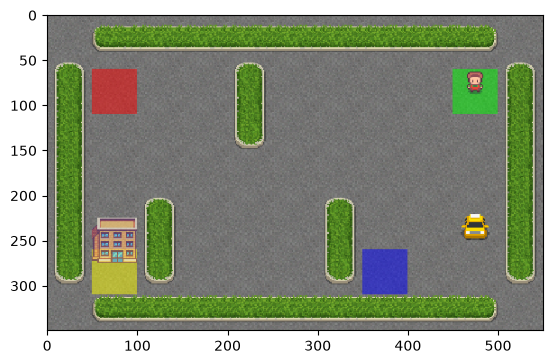

In [4]:
s, _ = env.reset(seed=SEED)
plt.imshow(env.render())

In [5]:
def play_and_train(env, agent, t_max=10**4):
    """
    This function should
    - run a full game, actions given by agent's e-greedy policy
    - train agent using agent.update(...) whenever it is possible
    - return total reward
    """
    total_reward = 0.0
    s, _ = env.reset()

    for t in range(t_max):
        # get agent to pick action given state s.
        # <YOUR CODE HERE>
        a = agent.get_action(s)          # epsilon-greedy action

        # </END OF YOUR CODE>

        next_s, r, terminated, truncated, _ = env.step(a)
        done = terminated
        # train (update) agent for state s
        # <YOUR CODE HERE>
        agent.update(s, a, r, next_s)    # Q-learning update with this transition

        # </END OF YOUR CODE>

        s = next_s
        total_reward += r
        if done:
            break

    return total_reward

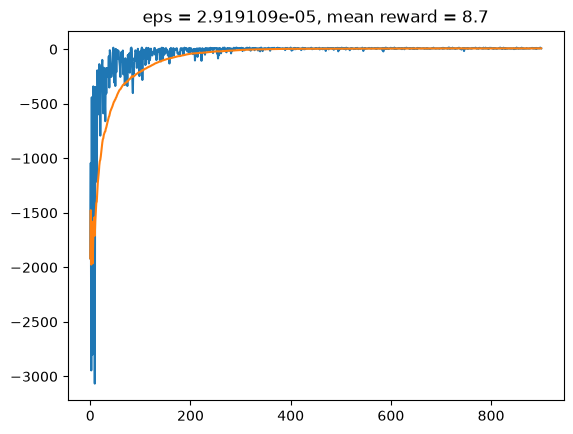

In [6]:
from IPython.display import clear_output

agent = QLearningAgent(alpha=0.5, epsilon=0.25, discount=0.99, env=env)

rewards = []
seed_everything(env)

for i in range(1000):
    rewards.append(play_and_train(env, agent))
    agent.epsilon *= 0.99

    if i % 100 == 0:
        clear_output(True)
        plt.title("eps = {:e}, mean reward = {:.1f}".format(agent.epsilon, np.mean(rewards[-10:])))
        plt.plot(rewards)
        plt.plot(moving_average(rewards))
        plt.show()

assert env.unwrapped.spec.id == "Taxi-v4" and np.mean(rewards[-100:]) >= 4.5, (
    "Please make sure that your agent is able to learn the optimal policy"
)

### (my addition) Watch my trained taxi
Using the notebook's `visualize_agent` helper with the greedy policy (`get_best_action`). The taxi should drive to the passenger, pick them up and drop them off.

In [7]:
taxi_agent = agent          # keep it, `agent` gets reused for CartPole below
taxi_rewards = list(rewards)
print(f"states seen: {len(taxi_agent._qvalues)} (Taxi has 500)")
print(f"mean reward of the last 100 episodes: {np.mean(taxi_rewards[-100:]):.2f}  (assert needs >= 4.5)")
print(f"final epsilon: {taxi_agent.epsilon:.2e}")

states seen: 404 (Taxi has 500)
mean reward of the last 100 episodes: 7.78  (assert needs >= 4.5)
final epsilon: 1.08e-05


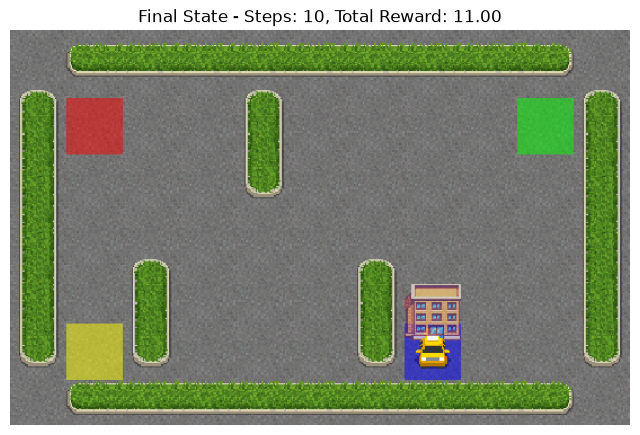

In [8]:
# (separate cell because visualize_agent clears its own cell's output while animating)
visualize_agent(env, taxi_agent, max_steps=30, delay=0.05)

# Seminar: Discretized state spaces

Use agent to train efficiently on `CartPole-v0`. This environment has a continuous set of possible states, so you will have to group them into bins somehow.

The simplest way is to use `round(x, n_digits)` (or `np.round`) to round a real number to a given amount of digits. The tricky part is to get the `n_digits` right for each state to train effectively.

Note that you don't need to convert state to integers, but to __tuples__ of any kind of values.

first state: [0.0051718  0.04594741 0.01238518 0.00479451]


/usr/local/lib/python3.11/dist-packages/gymnasium/envs/registration.py:513: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


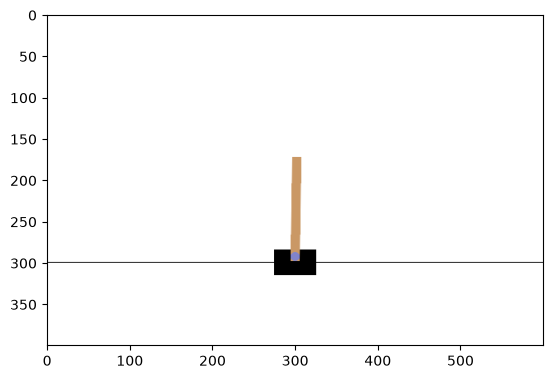

In [9]:
def make_env():
    return gym.make("CartPole-v0", render_mode="rgb_array").env  # .env unwraps the TimeLimit wrapper


env = make_env()
n_actions = env.action_space.n

print("first state: %s" % (env.reset()[0]))
plt.imshow(env.render())

### Play a few games

We need to estimate observation distributions. To do so, we'll play a few games and record all states.

In [10]:
def visualize_cartpole_observation_distribution(seen_observations):
    seen_observations = np.array(seen_observations)

    # The meaning of the observations is documented in
    # https://github.com/openai/gym/blob/master/gym/envs/classic_control/cartpole.py

    # Get the number of dimensions from the state
    n_dims = seen_observations.shape[1]

    f, axarr = plt.subplots(1, n_dims, figsize=(16, 4), sharey=True)
    titles = ["Cart Position", "Cart Velocity", "Pole Angle", "Pole Velocity At Tip"]

    for i in range(n_dims):
        ax = axarr[i]
        ax.hist(seen_observations[:, i], bins=20)
        ax.set_title(titles[i])
        xmin, xmax = ax.get_xlim()
        ax.set_xlim(min(xmin, -xmax), max(-xmin, xmax))
        ax.grid()
    f.tight_layout()

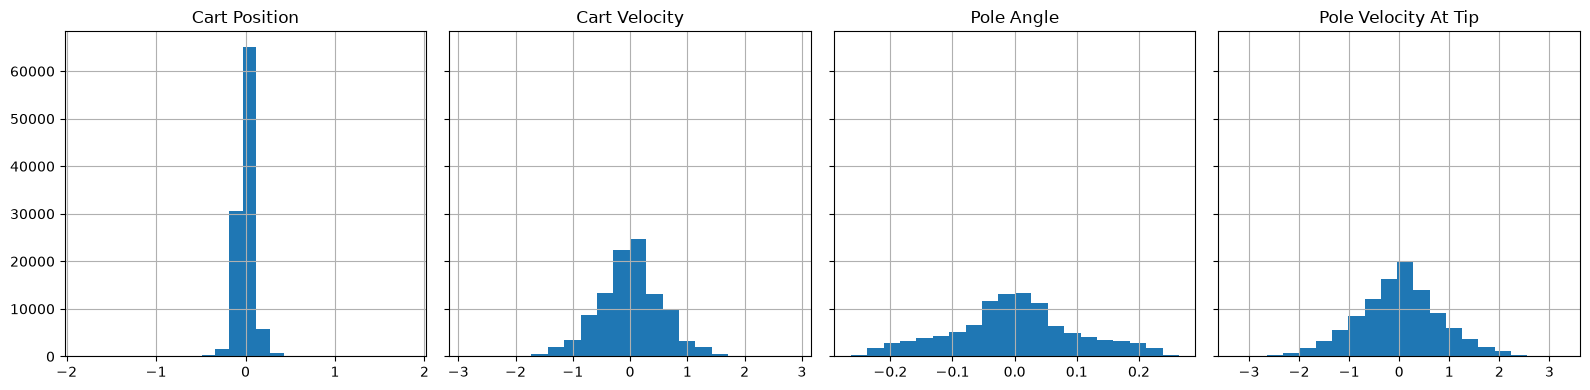

In [11]:
def gather_samples(env, max_steps=100000):
    seen_observations = []
    total_steps = 0

    while total_steps < max_steps:
        s, _ = env.reset()
        seen_observations.append(s)
        done = False

        while not done and total_steps < max_steps:
            s, r, done, _, _ = env.step(env.action_space.sample())
            seen_observations.append(s)
            total_steps += 1

        if total_steps >= max_steps:
            break

    return seen_observations


unwraped_env_samples = gather_samples(env)
visualize_cartpole_observation_distribution(unwraped_env_samples)

## Discretize environment

In [12]:
from gymnasium.core import ObservationWrapper


class Discretizer(ObservationWrapper):
    def __init__(self, env, n_digits):
        super().__init__(env)
        self.n_digits = n_digits

    def observation(self, state):
        # Hint: you can do that with round(x, n_digits).
        # You may pick a different n_digits for each dimension.

        # <YOUR CODE HERE>
        # n_digits can be one number for every dimension, or a list with one per dimension
        # e.g. [1, 1, 2, 1] -> cart position, cart velocity, pole angle (finer), pole velocity
        digits = np.broadcast_to(self.n_digits, np.shape(state))
        state = [round(float(x), int(d)) for x, d in zip(state, digits)]

        # </END OF YOUR CODE>

        return tuple(state)  # tuple to make it hashable

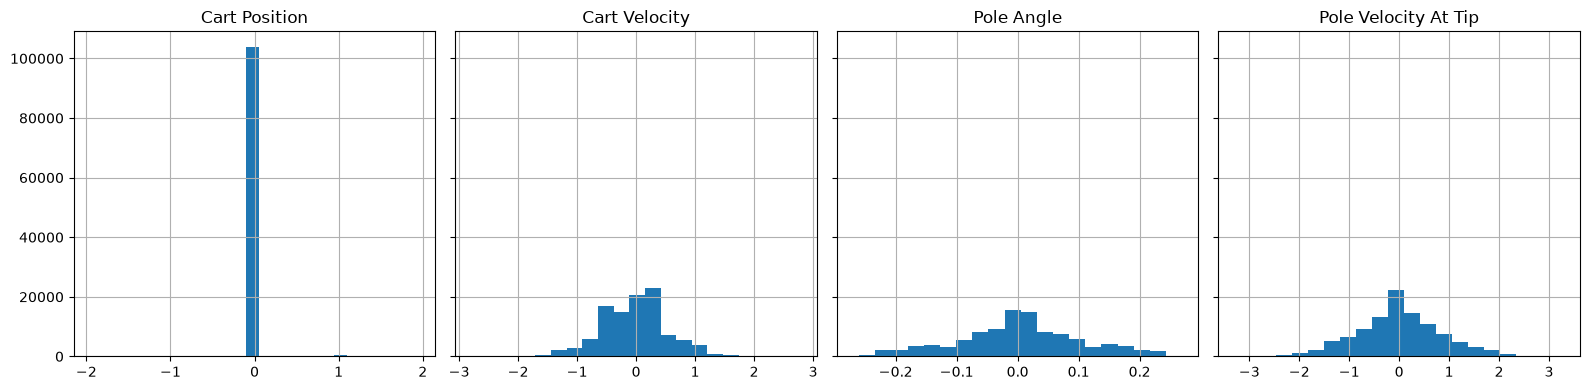

In [13]:
# (my choice) one number of digits per dimension: [cart position, cart velocity, pole angle, pole velocity]
# - pole angle only ranges about -0.2..0.2, so 1 digit = just ~5 bins -> 2 digits
# - cart position matters least -> whole numbers are enough (keeps the number of states down)
env = Discretizer(make_env(), n_digits=[0, 1, 2, 1])
seen_observations = gather_samples(env)
visualize_cartpole_observation_distribution(seen_observations)

## Learn discretized policy

Now let's train a policy that uses discretized state space.

__Tips:__

* Note that increasing the number of digits for one dimension of the observations increases your state space by a factor of $10$.
* If your discretization is too fine-grained, your agent will take much longer than 10000 steps to converge. You can either increase the number of iterations and reduce epsilon decay or change discretization. In practice we found that this kind of mistake is rather frequent.
* If your discretization is too coarse, your agent may fail to find the optimal policy. In practice we found that on this particular environment this kind of mistake is rare.
* **Start with a coarse discretization** and make it more fine-grained if that seems necessary.
* Having $10^3$–$10^4$ distinct states is recommended (`len(agent._qvalues)`), but not required.
* If things don't work without annealing $\varepsilon$, consider adding that, but make sure that it doesn't go to zero too quickly.

A reasonable agent should attain an average reward of at least 50.

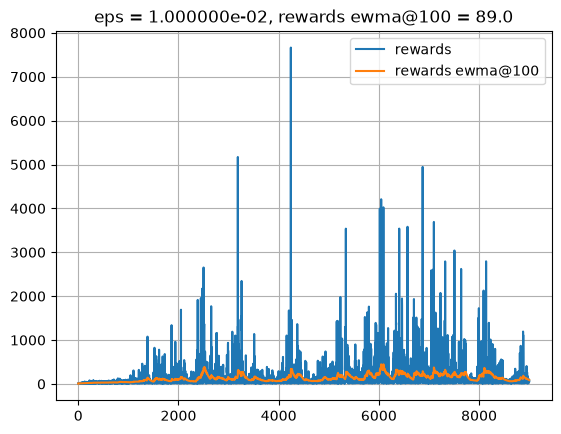

In [14]:
agent = QLearningAgent(alpha=0.5, epsilon=0.25, discount=0.99, env=env)

rewards, epsilons = [], []
seed_everything(env)

n_sessions = 10000
for i in range(n_sessions):
    reward = play_and_train(env, agent)
    rewards.append(reward)
    epsilons.append(agent.epsilon)

    # OPTIONAL: <YOUR CODE: adjust epsilon>
    # slowly shift from exploring to exploiting, but never all the way to 0
    agent.epsilon = max(0.01, agent.epsilon * 0.999)

    # END OF OPTIONAL: <YOUR CODE: adjust epsilon>


    if i % 1000 == 0:
        rewards_ewma = moving_average(rewards)

        clear_output(True)
        plt.plot(rewards, label="rewards")
        plt.plot(rewards_ewma, label="rewards ewma@100")
        plt.legend()
        plt.grid()
        plt.title("eps = {:e}, rewards ewma@100 = {:.1f}".format(agent.epsilon, rewards_ewma[-1]))
        plt.show()

### (my addition) How did it go?

In [15]:
print(f"distinct states visited: {len(agent._qvalues)}")
print(f"mean reward of the last 100 episodes: {np.mean(rewards[-100:]):.1f}")
print(f"ewma@100 at the end: {moving_average(rewards)[-1]:.1f}  (target: at least 50)")
print(f"best episode: {max(rewards):.0f} steps balanced | final epsilon: {agent.epsilon:.3f}")

# greedy test: no exploration at all
agent_eps = agent.epsilon
agent.epsilon = 0
test = [play_and_train(env, agent) for _ in range(20)]
agent.epsilon = agent_eps
print(f"greedy policy over 20 test episodes: mean {np.mean(test):.1f}, min {min(test):.0f}, max {max(test):.0f}")

distinct states visited: 4696
mean reward of the last 100 episodes: 105.1
ewma@100 at the end: 135.9  (target: at least 50)
best episode: 7664 steps balanced | final epsilon: 0.010
greedy policy over 20 test episodes: mean 755.4, min 31, max 3405


# (my addition) Extra: Q-learning vs Expected Value SARSA on CliffWalking
The setup cell defines `benchmark_agents(...)` but the seminar never uses it, so I used it for the next thing in the Practical_RL course: **Expected Value SARSA**. The only difference from Q-learning is the value of the next state:

* Q-learning: $V(s') = \max_{a'} Q(s', a')$ (assumes we'll act greedily next – *off-policy*)
* EV-SARSA: $V(s') = \sum_{a'} \pi(a'|s')\,Q(s', a')$ with the ε-greedy policy we're actually following (*on-policy*)

CliffWalking: walk from bottom-left to bottom-right, −1 per step, −100 (and back to start) for stepping into the cliff along the bottom edge.

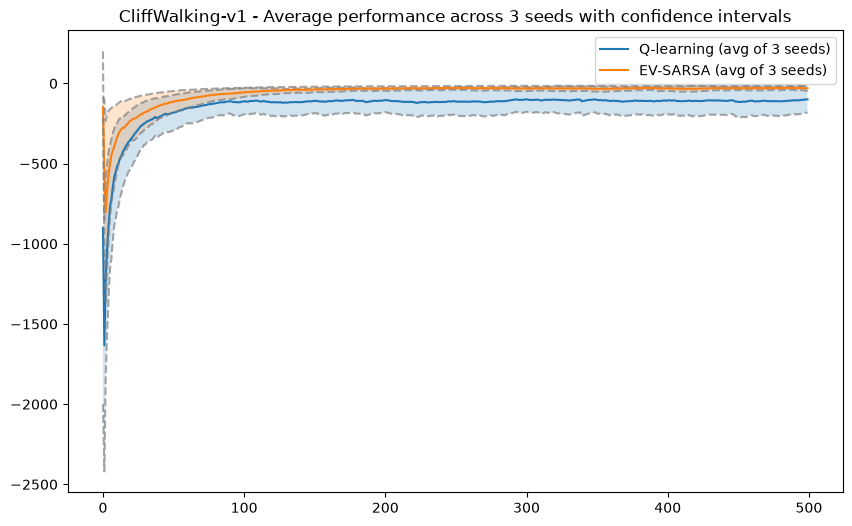

In [16]:
class EVSarsaAgent(QLearningAgent):
    """Expected Value SARSA - same as Q-learning except get_value."""

    def get_value(self, state):
        possible_actions = self.get_legal_actions(state)
        if len(possible_actions) == 0:
            return 0.0
        epsilon = self.epsilon
        best_action = self.get_best_action(state)
        n = len(possible_actions)
        # epsilon-greedy policy: every action gets epsilon/n, the best one gets an extra (1 - epsilon)
        state_value = 0.0
        for action in possible_actions:
            prob = epsilon / n + (1 - epsilon if action == best_action else 0)
            state_value += prob * self.get_qvalue(state, action)
        return state_value


exp_setups = [
    {"name": "Q-learning", "env": lambda: gym.make("CliffWalking-v1"),
     "agent_builder": lambda: QLearningAgent(alpha=0.25, epsilon=0.2, discount=0.99, env=None),
     "train_foo": play_and_train},
    {"name": "EV-SARSA", "env": lambda: gym.make("CliffWalking-v1"),
     "agent_builder": lambda: EVSarsaAgent(alpha=0.25, epsilon=0.2, discount=0.99, env=None),
     "train_foo": play_and_train},
]
avg_rewards = benchmark_agents(exp_setups, num_episodes=500, num_seeds=3)

Q-learning : average reward over the last 100 episodes (3 seeds) = -104.6
EV-SARSA   : average reward over the last 100 episodes (3 seeds) = -30.5


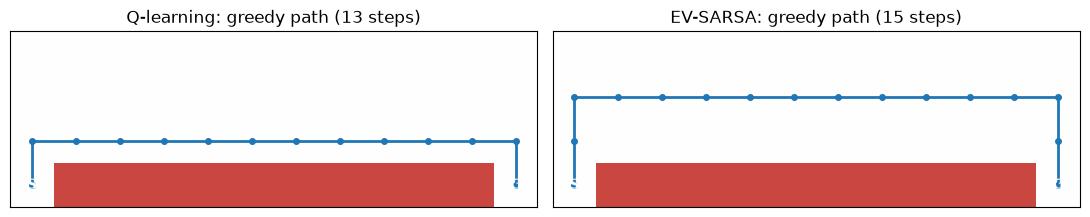

In [17]:
for name, r in avg_rewards.items():
    print(f"{name:<11}: average reward over the last 100 episodes (3 seeds) = {np.mean(r[-100:]):.1f}")

# train one agent of each kind and draw its greedy path on the 4x12 grid
def greedy_path(agent_cls):
    cliff_env = gym.make("CliffWalking-v1")
    ag = agent_cls(alpha=0.25, epsilon=0.2, discount=0.99, env=cliff_env)
    seed_everything(cliff_env)
    for _ in range(500):
        play_and_train(cliff_env, ag)
    s, _ = cliff_env.reset()
    path = [s]
    for _ in range(60):
        s, r, term, trunc, _ = cliff_env.step(ag.get_best_action(s))
        path.append(s)
        if term:
            break
    return path

fig, axes = plt.subplots(1, 2, figsize=(11, 2.4))
for ax, (name, cls) in zip(axes, [("Q-learning", QLearningAgent), ("EV-SARSA", EVSarsaAgent)]):
    grid = np.zeros((4, 12))
    grid[3, 1:11] = -1                                   # the cliff
    ax.imshow(grid, cmap="RdGy", vmin=-1.5, vmax=1.5)
    path = greedy_path(cls)
    rows, cols = np.unravel_index(path, (4, 12))
    ax.plot(cols, rows, "o-", color="tab:blue", lw=2, ms=4)
    ax.text(0, 3, "S", ha="center", va="center", fontweight="bold", color="white")
    ax.text(11, 3, "G", ha="center", va="center", fontweight="bold", color="white")
    ax.set_title(f"{name}: greedy path ({len(path) - 1} steps)"); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.savefig("figures/9_5_cliff_paths.png", dpi=150); plt.show()

**What I see:** EV-SARSA gets a much better reward *while learning* (about −31 vs −105 over the last 100 episodes), but the two greedy paths are different:

* **Q-learning** learns the **shortest path right along the edge of the cliff** (13 steps). Its target uses the *max* over next actions, i.e. it assumes it'll act perfectly from now on. But we keep exploring with ε = 0.2, so a random step next to the cliff often means falling in (−100) – that's why its online reward is so bad.
* **EV-SARSA**'s target averages over what the ε-greedy policy *actually* does, so it "knows" it might stumble and learns the **safer path one row further from the cliff** (15 steps).

So Q-learning = off-policy (learns the optimal policy, not the one it follows), EV-SARSA = on-policy (learns the value of the exploring policy it actually follows). If ε were decayed to 0 at the end, Q-learning's path would be the better one.